# Upworthy Research - Exploratory Data Analysis

Dataset: Upworthy Archive exploratory packages: March 12, 2020 release



In [2]:
import pandas as pd
import matplotlib.pyplot as py 
import numpy as np
import seaborn as sns

df_raw = pd.read_csv("../data/raw/upworthy-archive-exploratory-packages-03.12.2020.csv", index_col=0)

print("shape:", df_raw.shape, "\n")

df_raw.head()

shape: (22666, 16) 



,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,2014-11-20 06:43:16.005,2016-04-02 16:33:38.062,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3052,150,100.0,True,True,Anyone who's ever felt guilty about shopping a...,NaN,201446
1,2014-11-20 06:43:44.646,2016-04-02 16:25:54.021,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3033,122,14.0,False,False,Walmart is getting schooled by another retaile...,NaN,201446
2,2014-11-20 06:44:59.804,2016-04-02 16:25:54.024,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3092,110,1.8,False,False,Walmart may not be crapping their pants over t...,NaN,201446
3,2014-11-20 06:54:36.335,2016-04-02 16:25:54.027,546d902c26714c6c44000039,Things that matter. Pass 'em on.,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,this-is-what-sexism-against-men-sounds-like-am...,546bc55335992b86c8000043,3526,90,4.1,False,False,"If you ever wondered, ""but what about the men?...",NaN,201446
4,2014-11-20 06:54:57.878,2016-04-02 16:31:45.671,546d902c26714c6c44000039,Things that matter. Pass 'em on.,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,this-is-what-sexism-against-men-sounds-like-am...,546d900426714cd2dd00002e,3506,120,100.0,True,False,"If you ever wondered, ""but what about the men?...",NaN,201446


In [3]:
df_raw.index.is_unique

True

In [4]:
df_raw.duplicated().sum()

np.int64(0)

In [5]:
audit = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'missing_values': df_raw.isna().sum(),
    'missing_values_percentage': (df_raw.isna().mean() * 100).round(2),
    'unique_values': df_raw.nunique(dropna = True)
    
})

audit

,dtype,missing_values,missing_values_percentage,unique_values
created_at,str,0,0.00,22665
updated_at,str,0,0.00,22666
clickability_test_id,str,0,0.00,4873
excerpt,str,2417,10.66,3507
headline,str,0,0.00,12387
lede,str,12,0.05,4309
slug,str,0,0.00,22334
eyecatcher_id,str,22,0.10,9678
impressions,int64,0,0.00,5170
clicks,int64,0,0.00,341


The columns most relevant to this project are `clickability_test_id`, `headline`, `lede`, `excerpt`, `impressions`, `clicks`, `significance`, `winner`, `first_place`, `test_week`, and `eyecatcher_id`.

In [6]:
cols = ['clickability_test_id', 'headline', 'lede', 'excerpt', 'impressions', 'clicks', 'significance', 'winner', 'first_place', 'test_week', 'eyecatcher_id']
df = df_raw[cols].copy()

In [7]:
df.head(10)

,clickability_test_id,headline,lede,excerpt,impressions,clicks,significance,winner,first_place,test_week,eyecatcher_id
0,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3052,150,100.0,True,True,201446,546d6fa19ad54eec8d00002d
1,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3033,122,14.0,False,False,201446,546d6fa19ad54eec8d00002d
2,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3092,110,1.8,False,False,201446,546d6fa19ad54eec8d00002d
3,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3526,90,4.1,False,False,201446,546bc55335992b86c8000043
4,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3506,120,100.0,False,True,201446,546d900426714cd2dd00002e
5,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3380,98,25.3,False,False,201446,546d900426714c6c44000038
6,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3465,75,0.2,False,False,201446,546d900426714c1ad900001e
7,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3431,86,3.2,False,False,201446,546d900484ad38b2ce000027
8,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3394,76,0.5,False,False,201446,546d900484ad385a0a000038
9,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3505,95,11.6,False,False,201446,546d900484ad381bbe00002b


In [8]:
df.describe()

,impressions,clicks,significance,test_week
count,22666.000000,22666.000000,22666.000000,22666.000000
mean,3574.700035,54.319598,40.733826,201417.975382
std,1437.948530,46.839176,39.670098,56.344639
min,13.000000,0.000000,0.000000,201303.000000
25%,2740.000000,24.000000,2.800000,201402.000000
50%,3122.000000,42.000000,25.700000,201430.000000
75%,4091.000000,70.000000,85.400000,201444.000000
max,25314.000000,975.000000,100.000000,201517.000000


In [9]:
test_id_metrics = df.groupby('clickability_test_id').size().describe().round(3)
test_id_metrics

count    4873.000
mean        4.651
std         1.186
min         2.000
25%         4.000
50%         4.000
75%         5.000
max        14.000
dtype: float64

In [10]:
largest_package_id = (df['clickability_test_id'].value_counts() == 14).index[0]

df[df['clickability_test_id'] == largest_package_id]

,clickability_test_id,headline,lede,excerpt,impressions,clicks,significance,winner,first_place,test_week,eyecatcher_id
83400,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2196,77,0.0,False,False,201414,53480048be415444ed000006
83471,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2288,88,0.0,False,False,201414,5348004dbe4154c576000008
83712,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2217,78,0.0,False,True,201414,53471a028f171a2b85000007
83803,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2282,80,0.0,False,False,201414,53480048be4154b03a00000f
83988,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2183,76,0.0,False,False,201414,5348004bbe4154b7bb000006
84098,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2234,71,0.0,False,False,201414,534723d368065ae029000005
84239,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2277,72,0.0,False,False,201414,53480048be4154f1fb00000b
84463,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2141,65,0.0,False,False,201414,5348004968065ae029000017
84470,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2110,80,0.0,False,False,201414,5348004868065a9d3400000f
84778,53480581be4154443a000008,This Dad Has A Message To The Boys Who Want To...,"<p>DISCLOSURE: I have a daughter. Someday, she...",Things that matter. Pass 'em on.,2209,61,0.0,False,False,201414,5348004b68065a6421000018


**Average Variants**

Each article had a average of 4.651 different variants (tests), and a test with the most variants at 14. The  test with 14 variants was observed and no irregularities were found


In [11]:
winner_count_per_id = df.groupby('clickability_test_id')['winner'].sum().value_counts()
winner_count_per_id

winner
0    3722
1    1150
2       1
Name: count, dtype: int64

In [12]:
test_counts = df.groupby('clickability_test_id')['winner'].sum()
bad_test_id = test_counts[test_counts == 2].index[0]

df[df['clickability_test_id'] == bad_test_id]

,clickability_test_id,headline,lede,excerpt,impressions,clicks,significance,winner,first_place,test_week,eyecatcher_id
678,547278e0ce85339079000038,A 13-Year-Old Came Out To His Best Bro And The...,"<p>Sometimes, as we push for equality, the wor...",And the #BreakTheInternetAward goes to ....,3717,89,31.0,True,False,201447,546fa5e187942a1fe2000069
133159,547278e0ce85339079000038,A 13-Year-Old Came Out To His Best Bro And The...,"<p>Sometimes, as we push for equality, the wor...",Things that matter. Pass 'em on.,3713,98,82.1,False,False,201447,546fa5e187942a1fe2000069
133460,547278e0ce85339079000038,A 13-Year-Old Came Out To His Best Bro And The...,"<p>Sometimes, as we push for equality, the wor...",So much good is happening here.,3635,100,99.6,True,False,201447,546fa5e187942a1fe2000069
134542,547278e0ce85339079000038,A 13-Year-Old Came Out To His Best Bro And The...,"<p>Sometimes, as we push for equality, the wor...",This is the right direction.,3674,101,100.0,False,True,201447,546fa5e187942a1fe2000069


In [13]:
df['winner_count_anomaly'] = df['clickability_test_id'].isin(test_counts[test_counts != 1].index)
df.head()

,clickability_test_id,headline,lede,excerpt,impressions,clicks,significance,winner,first_place,test_week,eyecatcher_id,winner_count_anomaly
0,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3052,150,100.0,True,True,201446,546d6fa19ad54eec8d00002d,False
1,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3033,122,14.0,False,False,201446,546d6fa19ad54eec8d00002d,False
2,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3092,110,1.8,False,False,201446,546d6fa19ad54eec8d00002d,False
3,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3526,90,4.1,False,False,201446,546bc55335992b86c8000043,True
4,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3506,120,100.0,False,True,201446,546d900426714cd2dd00002e,True


**Winner Anomalies**


One test was found with two rows flagged as `winner`, and 3,722 tests had no `winner` recorded. Rather than dropping these cases, they were flagged using a new `winner_count_anomaly` column, which identifies any test with zero or multiple winners for further review.

In [14]:
pd.crosstab(df['winner'], df['first_place'])

first_place,False,True
winner,,
False,17560,3954
True,283,869


In [15]:
pd.crosstab(df['first_place'], df['significance'] == 100)

significance,False,True
first_place,,
False,17842,1
True,50,4773


**first_place relationships**


A crosstab of `winner` and `first_place` shows a moderate relationship between the two. A stronger relationship emerges between `first_place` and `significance == 100`, suggesting `first_place` may be derived directly from reaching this threshold.

<Axes: title={'center': 'significance'}, xlabel='first_place'>

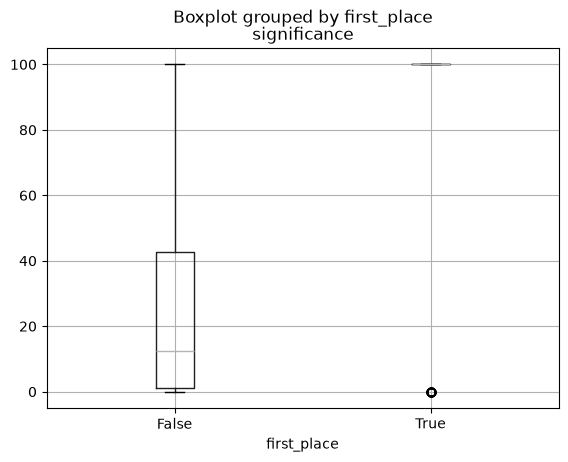

In [16]:
df.boxplot(column= 'significance', by = 'first_place')

In [17]:
print( (df['impressions'] == 0).sum() )
print ((df['clicks'] == 0).sum())
df.describe()

0
12


,impressions,clicks,significance,test_week
count,22666.000000,22666.000000,22666.000000,22666.000000
mean,3574.700035,54.319598,40.733826,201417.975382
std,1437.948530,46.839176,39.670098,56.344639
min,13.000000,0.000000,0.000000,201303.000000
25%,2740.000000,24.000000,2.800000,201402.000000
50%,3122.000000,42.000000,25.700000,201430.000000
75%,4091.000000,70.000000,85.400000,201444.000000
max,25314.000000,975.000000,100.000000,201517.000000


In [18]:
group_avg = df.groupby('clickability_test_id')[['clicks','impressions']].mean()
(group_avg == 0).sum()

clicks         1
impressions    0
dtype: int64

In [19]:
zero_impression_tests = group_avg[group_avg['clicks'] == 0].index
df[df['clickability_test_id'].isin(zero_impression_tests)]

,clickability_test_id,headline,lede,excerpt,impressions,clicks,significance,winner,first_place,test_week,eyecatcher_id,winner_count_anomaly
80775,53507921f6bdf72973000006,Economist Paul Krugman Lays Out The Basics Of ...,<p>A few definitions to tee this up:</p><p><st...,Things that matter. Pass 'em on.,24,0,0.0,False,False,201415,53504f75b921b4d66a000059,True
87423,53507921f6bdf72973000006,Economist Paul Krugman Lays Out The Basics Of ...,<p>A few definitions to tee this up:</p><p><st...,What words like ‘Gilded Age’ and ‘Oligarchy’ r...,21,0,0.0,False,False,201415,53504f75b921b4d66a000059,True
87792,53507921f6bdf72973000006,Economist Paul Krugman Lays Out The Basics Of ...,<p>A few definitions to tee this up:</p><p><st...,A top economist sits down to talk about what’s...,13,0,0.0,False,False,201415,53504f75b921b4d66a000059,True
88900,53507921f6bdf72973000006,Economist Paul Krugman Lays Out The Basics Of ...,<p>A few definitions to tee this up:</p><p><st...,An economist explains what folks really mean w...,28,0,0.0,False,False,201415,53504f75b921b4d66a000059,True


In [20]:
df['ctr'] = df['clicks'] / df['impressions'].replace(0, np.nan)
df['ctr'].describe()

count    22666.000000
mean         0.015754
std          0.012289
min          0.000000
25%          0.007463
50%          0.012537
75%          0.020281
max          0.136063
Name: ctr, dtype: float64

**Impression and Clicks analysis**

On inspection, `impressions` and `clicks` show no unusual values. Zero and no-click rows were investigated individually; a single zero-click column was determined to be a plausible outcome. A `ctr` (click-through rate) column was added for use in later analysis



In [21]:
significance_100_percentage = ((df['significance'] == 100).sum() / len(df) * 100).round(3)
significance_100_percentage

np.float64(21.062)

In [22]:
(df['significance'] == 100).sum()

np.int64(4774)

In [23]:
df['significance'].describe()

count    22666.000000
mean        40.733826
std         39.670098
min          0.000000
25%          2.800000
50%         25.700000
75%         85.400000
max        100.000000
Name: significance, dtype: float64

In [24]:
df['significance'].value_counts().sort_index()

significance
0.0      2270
0.1       520
0.2       341
0.3       255
0.4       189
         ... 
99.6        8
99.7        9
99.8        3
99.9        6
100.0    4774
Name: count, Length: 998, dtype: int64

In [25]:
df['significance'].nunique()

998

<Axes: xlabel='winner', ylabel='significance'>

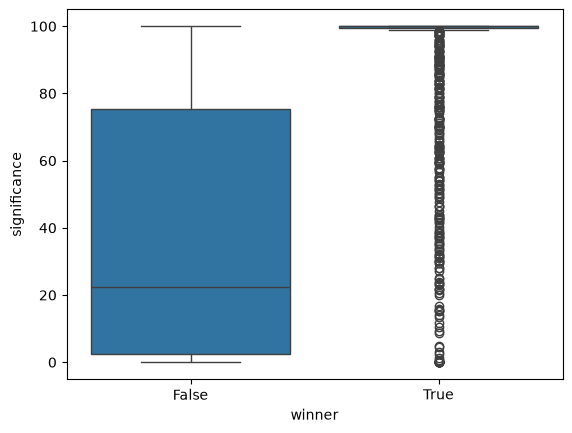

In [26]:
sns.boxplot(data=df, x='winner', y='significance')

In [27]:
sub_100_winners = (df[df['winner']]['significance'] < 100).sum()
sub_100_winners

np.int64(291)

In [28]:
df.groupby('clickability_test_id')['significance'].agg(['min','max','std'])

,min,max,std
clickability_test_id,,,
51436061220cb800020001e7,0.8,100.0,45.951088
51436069220cb800020005ae,0.0,100.0,44.589606
51436069220cb800020005bd,23.0,100.0,54.447222
5143606a220cb800020005c6,0.0,100.0,49.736439
5143606b220cb800020005d7,0.0,100.0,43.832032
...,...,...,...
554036c1393131000c330100,3.3,100.0,39.478268
55403be0393131002cf60000,1.8,100.0,48.111329
55413ef4333531000c180000,2.1,100.0,69.225754


Text(0.5, 1.0, 'Distribution of Significance Values')

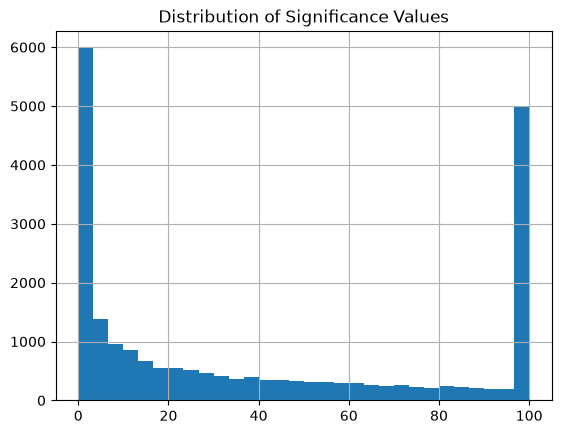

In [29]:
ax = df['significance'].hist(bins = 30)
ax.set_title('Distribution of Significance Values')

`significance` does not seem to be a p-value. It ranges from 0 to 100.0, with a large concentration at the extremes of 0 and at 100. `significance == 100` closely aligns with `first_place == true`(see crosstab). Given that significance seems bucketed rather than continuous, a independent statistical measure such as a two-proportion z-test should be computed in a later notebook




In [30]:
winner_matches = df.groupby('clickability_test_id').apply(
    lambda g: g.loc[g['significance'].idxmax(), 'winner']
)
winner_matches.value_counts()

False    4008
True      865
Name: count, dtype: int64

In [31]:
first_place_matches = df.groupby('clickability_test_id').apply(
    lambda g: g.loc[g['significance'].idxmax(), 'first_place']
)
first_place_matches.value_counts()

True     4801
False      72
Name: count, dtype: int64

In [32]:
single_winner = df[df['clickability_test_id'].isin(test_counts[test_counts == 1].index)]

def winner_matches(g, col):
    return g.loc[g[col] == g[col].max(), 'winner'].any()

sig_match = single_winner.groupby('clickability_test_id').apply(winner_matches, col='significance')
ctr_match = single_winner.groupby('clickability_test_id').apply(winner_matches, col='ctr')

print(sig_match.value_counts(normalize=True) * 100)
print(ctr_match.value_counts(normalize=True) * 100)
print('overlap:', (sig_match[~sig_match].index.isin(ctr_match[~ctr_match].index)).sum())

True     76.521739
False    23.478261
Name: proportion, dtype: float64
True     74.782609
False    25.217391
Name: proportion, dtype: float64
overlap: 228


**Winner Validation:**

Initial validation with `idxmax` suggested `winner` was poorly explained by `significance` (17.7% match) and moderately well by `first_place` (98.5%)

After restricting to tests wtih exactly one winner and checking if it falls within the max values, winner is well explained by both `significance` and `ctr`.

Of the tests where `winner` did not align with either metric, 228 failed both checks


In [33]:
group_sizes = df.groupby('clickability_test_id').size()
group_sizes.value_counts().sort_index()

2      127
3      182
4     2516
5      928
6      865
7      134
8       86
9       18
10       7
11       8
12       1
14       1
Name: count, dtype: int64

In [34]:
group_sizes.describe()

count    4873.000000
mean        4.651344
std         1.185801
min         2.000000
25%         4.000000
50%         4.000000
75%         5.000000
max        14.000000
dtype: float64

In [35]:
print('Group Sizes Median:', group_sizes.median())
print('Group Sizes Mode:', group_sizes.mode()[0])


Group Sizes Median: 4.0
Group Sizes Mode: 4


Text(0.5, 1.0, 'Distribution of the group sizes of clickability_test_id')

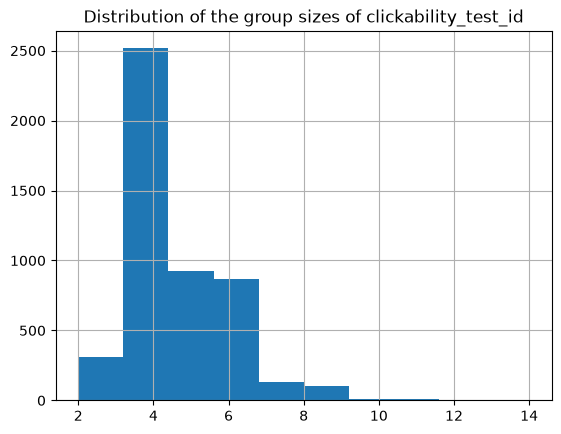

In [36]:
ax = group_sizes.hist()
ax.set_title('Distribution of the group sizes of clickability_test_id')

This histogram visualizes the distribution of variant counts (group sizes) across all `clickability_test_id` groups.

In [37]:
df.duplicated(subset = 'headline').sum()

np.int64(10279)

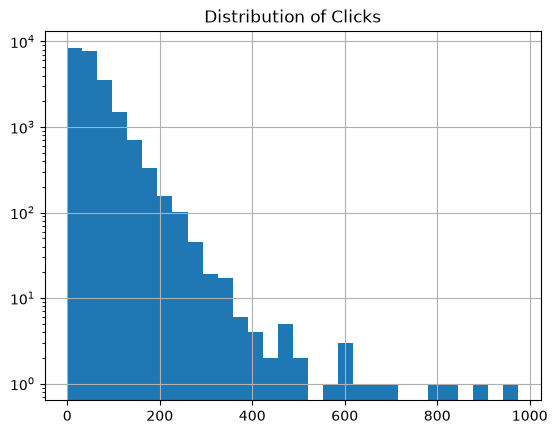

In [38]:
ax = df['clicks'].hist(bins = 30)
ax.set_title('Distribution of Clicks')
py.yscale('log')

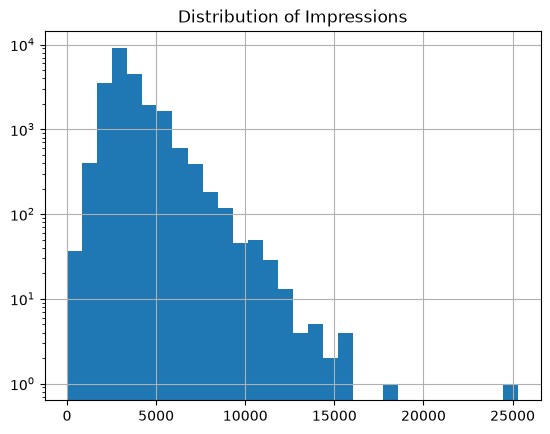

In [39]:
ax = df['impressions'].hist(bins = 30)
ax.set_title('Distribution of Impressions')
py.yscale('log')

Text(0.5, 1.0, 'Distribution of CTR')

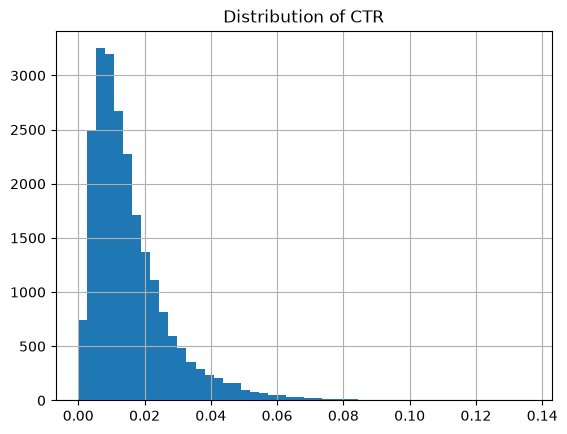

In [40]:
ax = df['ctr'].hist(bins = 50)
ax.set_title('Distribution of CTR')


Both `clicks` and `impressions` are both heavily right skewed: resulting in a right skewed `ctr`



In [41]:
df['test_week'].value_counts().sort_index(ascending = False)

test_week
201517    114
201516    175
201515    170
201514    182
201513    181
         ... 
201307     24
201306     31
201305     15
201304      4
201303      3
Name: count, Length: 121, dtype: int64

In [42]:
earliest_week = df['test_week'].min()
latest_week = df['test_week'].max()

print(earliest_week)
print(latest_week)

201303
201517


In [43]:
num_unique_weeks = df['test_week'].nunique()
num_unique_weeks

121

In [44]:
all_weeks = set(range(df['test_week'].min(), df['test_week'].max() + 1))
present_weeks = set(df['test_week'].unique())
missing_weeks = sorted(all_weeks - present_weeks)
len(missing_weeks)

94

<Axes: xlabel='test_week'>

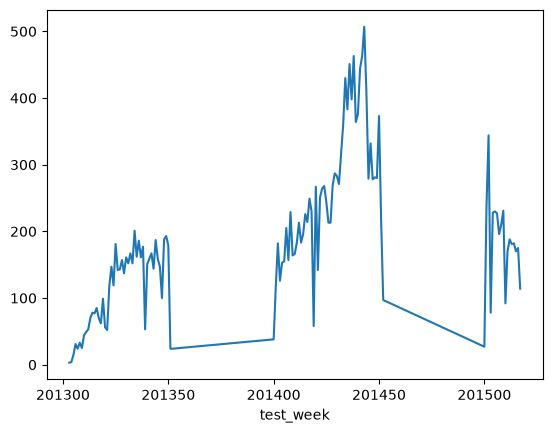

In [45]:
weekly_counts = df['test_week'].value_counts().sort_index()
weekly_counts.plot(kind = 'line')

In [46]:
print('earliest:', earliest_week, 'latest:', latest_week)
print('unique weeks present:', num_unique_weeks, '/ possible:', latest_week - earliest_week + 1)
print('missing weeks:', len(missing_weeks))

earliest: 201303 latest: 201517
unique weeks present: 121 / possible: 215
missing weeks: 94


**Test Week**

`test_week` ranges from `earliest_week` to `latest_week`: 2013-03-03  to 2015-05-17 

There were 94 weeks without tests, primarily between March of 2013 to April of 2014 and May of 2014 to the start of 2015 

In [47]:
headline_variety = df.groupby('clickability_test_id')['headline'].nunique()
unchanged_tests = (headline_variety == 1).sum()
proportion_unchanged = unchanged_tests / len(headline_variety) * 100

print(unchanged_tests, proportion_unchanged.round(2))

2266 46.5


In [48]:
unchanged_ids = headline_variety[headline_variety == 1].index
df[df['clickability_test_id'].isin(unchanged_ids)].head(10)

,clickability_test_id,headline,lede,excerpt,impressions,clicks,significance,winner,first_place,test_week,eyecatcher_id,winner_count_anomaly,ctr
0,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3052,150,100.0,True,True,201446,546d6fa19ad54eec8d00002d,False,0.049148
1,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3033,122,14.0,False,False,201446,546d6fa19ad54eec8d00002d,False,0.040224
2,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",Things that matter. Pass 'em on.,3092,110,1.8,False,False,201446,546d6fa19ad54eec8d00002d,False,0.035576
3,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3526,90,4.1,False,False,201446,546bc55335992b86c8000043,True,0.025525
4,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3506,120,100.0,False,True,201446,546d900426714cd2dd00002e,True,0.034227
5,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3380,98,25.3,False,False,201446,546d900426714c6c44000038,True,0.028994
6,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3465,75,0.2,False,False,201446,546d900426714c1ad900001e,True,0.021645
7,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3431,86,3.2,False,False,201446,546d900484ad38b2ce000027,True,0.025066
8,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3394,76,0.5,False,False,201446,546d900484ad385a0a000038,True,0.022392
9,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,Things that matter. Pass 'em on.,3505,95,11.6,False,False,201446,546d900484ad381bbe00002b,True,0.027104


**Headline investigation**

Found that there are 2266 unique tests where the headline is unchanged throughout each package (46.5% of all tests), indicating that a substantial portion of the database may represent non-headline experiments




In [49]:
unchanged_ids = headline_variety[headline_variety == 1].index
unchanged_df = df_raw[df_raw['clickability_test_id'].isin(unchanged_ids)]

unchanged_df.groupby('clickability_test_id')['eyecatcher_id'].nunique().value_counts()

eyecatcher_id
1     838
4     637
5     289
6     269
3      71
2      66
7      44
8      35
11      5
10      5
9       4
0       2
14      1
Name: count, dtype: int64

In [50]:
both_unchanged_ids = unchanged_df.groupby('clickability_test_id')['eyecatcher_id'].nunique()
both_unchanged_ids = both_unchanged_ids[both_unchanged_ids == 1].index

both_unchanged_df = df_raw[df_raw['clickability_test_id'].isin(both_unchanged_ids)]
both_unchanged_df.head(10)

,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,2014-11-20 06:43:16.005,2016-04-02 16:33:38.062,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3052,150,100.0,True,True,Anyone who's ever felt guilty about shopping a...,NaN,201446
1,2014-11-20 06:43:44.646,2016-04-02 16:25:54.021,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3033,122,14.0,False,False,Walmart is getting schooled by another retaile...,NaN,201446
2,2014-11-20 06:44:59.804,2016-04-02 16:25:54.024,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3092,110,1.8,False,False,Walmart may not be crapping their pants over t...,NaN,201446
79,2014-11-20 14:27:14.957,2016-04-02 16:25:54.12,546dfa4226714c0538000064,Things that matter. Pass 'em on.,A Bunch Of Celebrities Recorded A Song To Rais...,"<p>In November 2014, singer/songerwriter Bob G...",a-bunch-of-celebrities-recorded-a-song-to-rais...,546df33b84ad3834f000004c,3848,220,100.0,True,True,Powerful quotes from the musician who turned d...,NaN,201446
80,2014-11-20 14:27:38.304,2016-04-02 16:31:40.756,546dfa4226714c0538000064,He didn't want to say no. He had to.,A Bunch Of Celebrities Recorded A Song To Rais...,"<p>In November 2014, singer/songerwriter Bob G...",a-bunch-of-celebrities-recorded-a-song-to-rais...,546df33b84ad3834f000004c,3948,181,2.7,False,False,Powerful quotes from the musician who turned d...,NaN,201446
81,2014-11-20 14:28:28.553,2016-04-02 16:31:46.906,546dfa4226714c0538000064,"Uh, yeah they have Christmas in Africa.",A Bunch Of Celebrities Recorded A Song To Rais...,"<p>In November 2014, singer/songerwriter Bob G...",a-bunch-of-celebrities-recorded-a-song-to-rais...,546df33b84ad3834f000004c,3839,182,6.1,False,False,Powerful quotes from the musician who turned d...,NaN,201446
82,2014-11-20 14:29:15.311,2016-04-02 16:25:54.122,546dfa4226714c0538000064,"They've already raised millions, but at what c...",A Bunch Of Celebrities Recorded A Song To Rais...,"<p>In November 2014, singer/songerwriter Bob G...",a-bunch-of-celebrities-recorded-a-song-to-rais...,546df33b84ad3834f000004c,3845,186,12.0,False,False,Powerful quotes from the musician who turned d...,NaN,201446
297,2014-11-21 00:01:52.201,2016-04-02 16:31:40.845,546e80f084ad380752000096,Things that matter. Pass 'em on.,Kim Jong Un Would Really Hate For You To Watch...,"<p>At age 21, Yeonmi Park is a brand new activ...",kim-jong-un-would-really-hate-for-you-to-watch...,546df39a84ad380b59000037,3101,116,100.0,True,False,I thought I knew what life was like in North K...,NaN,201446
300,2014-11-21 00:06:27.137,2016-04-02 16:31:40.848,546e80f084ad380752000096,"“North Korea is indescribable,” she said.",Kim Jong Un Would Really Hate For You To Watch...,"<p>At age 21, Yeonmi Park is a brand new activ...",kim-jong-un-would-really-hate-for-you-to-watch...,546df39a84ad380b59000037,3042,106,59.4,False,False,I thought I knew what life was like in North K...,NaN,201446
301,2014-11-21 00:07:35.484,2016-04-02 16:31:40.85,546e80f084ad380752000096,“...the only country in the world that execute...,Kim Jong Un Would Really Hate For You To Watch...,"<p>At age 21, Yeonmi Park is a brand new activ...",kim-jong-un-would-really-hate-for-you-to-watch...,546df39a84ad380b59000037,3092,111,74.8,False,False,I thought I knew what life was like in North K...,NaN,201446


**Eyecatcher id investigation:**

Only 838 out of 2266 tests with unchanged headlines have unchanged eyecatcher_id, confirming that image/thumbnail tests are as important as headline tests.

The 838 show no variation in headlines or eyecatcher_ids:



In [51]:
df_raw.groupby('winner')['excerpt'].apply(lambda x: x.isna().mean())

winner
False    0.108534
True     0.071181
Name: excerpt, dtype: float64

In [52]:
excerpt_variety = df_raw.groupby('clickability_test_id')['excerpt'].nunique(dropna=True)
excerpt_variety.value_counts().sort_index()

excerpt
0      471
1     3568
2      224
3      119
4      341
5       86
6       49
7       10
8        3
10       1
11       1
Name: count, dtype: int64

**Excerpt investigation: **

Leakage check returns similar percentages for `winner` and non-winners, suggesting that `excerpt` is not a outcome artifact when missing vs non-missing


In [53]:
excerpt_check = both_unchanged_df.groupby('clickability_test_id')['excerpt'].nunique(dropna=True)
excerpt_check.value_counts().sort_index()

excerpt
0      63
1     276
2      26
3      51
4     290
5      73
6      44
7      10
8       3
10      1
11      1
Name: count, dtype: int64

In [54]:
unexplained_ids = excerpt_check[excerpt_check <= 1].index
len(unexplained_ids)

339

Out of the 838 tests unexplained by headline/eyecatcher, only 339 of them cannot be explained by excerpt varying

# Summary of Findings

22666 rows: one row per variant, grouped under `clickability_test_id` with 4873 unique tests. Average of 4.65 variants per test

Working columns: `clickability_test_id`, `headline`, `lede`, `excerpt`, 
`impressions`, `clicks`, `significance`, `winner`, `first_place`, 
`test_week`, `eyecatcher_id`. `share_text` 

**Winner / first_place / significance**
- `significance` ranges 0 - 100 (not a p-value), heavily concentrated at the extremes (2,270 at exactly 0, 4,774 at exactly 100), with 998 unique values. Not continuous but    bucketed/directed
- `significance == 100` aligns with `first_place == true` with 998 unique cases
- 3,722 tests have 0 winners, 1,150 have exactly 1, and 1 test has 2 winners. Flagged via `winner_count_anomaly` rather than dropped.
- A first `idxmax`-based check initially suggested `winner` was poorly explained by significance (17.7% match) — this was from ties at `significance == 100` and contamination by zero/multi-winner tests, not a real inconsistency.
- Restricting to the 1,150 single-winner tests and checking membership among tied max values: winner matches max significance in 76.5% of cases and max CTR in 74.8% of cases with 228 tests failing both checks — a small, consistent group worth flagging as re-evaluation candidates.

**Impressions / clicks / CTR**
- No 0 impression rows; 12 0-click rows; all plausible outcomes
- `ctr = clicks / impressions`, mean = ~1.6%; right skewed
- Clicks, impressions, and ctr are all right-skewed, visualized using log scale

**test_week**
- Spans 201303–201517 (215 possible weeks), with only 121 weeks actually present — 94 missing, concentrated between March 2013–April 2014 and May 2014–early 2015.

**Headline variation and unexplained residual**
- 46.5% of tests (2,266) do not vary headline text across variants.
- Of those, 1,428 (63%) vary `eyecatcher_id`, indicating image/thumbnail tests rather than true headline tests.
- Of the remaining 838 tests (unchanged headline + eyecatcher), 499 vary `excerpt`, leaving 339 tests where headline, eyecatcher_id, and excerpt are all unchanged across every variant, leaving a 7% unexplained residual

**Open flags carried into notebook 2/3**
- `winner_count_anomaly` — 0 or 2+ winners per test
- 228 tests where winner matches neither max significance nor max CTR
- 339 tests with no observable content variation across variants — 
  `no_observable_variation` candidate flag
- No formal low-impression confidence threshold set yet 


